# PhenoTest Graphing
We ran some LO trials on many worms so that we could sort worms into high, medium, and low responders. Then we ran Jacobson-style CC trials on those worms to compare whether conditioning outcomes were different depending on how light-reactive the worms were by default. The CSV here contains R1 and R3 of the original R1-R6, where R1,3,5 were the high,med,low CC group, and R2,4,6  were the high,med,low PC group. 

## Import packages, preprocessing data for NaNs and filling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set file path
#CSV_FILEPATH = '/Users/zacharykelso/Desktop/Planarian_paper/R_Stats_EXPORT.csv'         # My original data
CSV_FILEPATH = '../hand_scored_datasheets/R_Stats_Sage_Unblinded_data.csv'           # Sage data

# Read the CSV
#df = pd.read_csv(CSV_FILEPATH)  # worked before I hit option-space somewhere, annoying mac bullshit
df = pd.read_csv(CSV_FILEPATH, encoding='mac_roman')

# Forward fill the group_day column to fill empty cells
df['group_day'] = df['group_day'].replace('', np.nan)
df['group_day'] = df['group_day'].fillna(method='ffill')

# Convert W1-W6 columns to numeric, coercing errors to NaN
worm_columns = ['W1', 'W2', 'W3', 'W4', 'W5', 'W6']
for col in worm_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert BlockNum to numeric
df['BlockNum'] = pd.to_numeric(df['BlockNum'], errors='coerce')

print("Data loaded and preprocessed successfully!")
print(f"Total rows: {len(df)}")
print(f"Unique group_day values: {df['group_day'].unique()}")
print(f"BlockNum range: {df['BlockNum'].min()} to {df['BlockNum'].max()}")

FileNotFoundError: [Errno 2] No such file or directory: '../hand_scored_datasheets/R_Stats_Sage_Unblinded_data.csv'

## Define graphing function

In [2]:
def create_graphs(data, groups=['R1', 'R2', 'R3', 'R4', 'R5', 'R6'], blocks=None, 
                  error_type='SEM', figsize=(10, 6),
                  title='Performance Across Blocks',
                  ylabel='Average Score',
                  y_values='probability',
                  ylim='auto', ylim_padding=0.1,
                  save=False, filename='block_performance.png',
                  show_error_bars=True):
    """
    Creates a line graph showing average performance across blocks for different groups.
    
    NOTE: This function handles variable trial counts automatically. It collects ALL trials 
    for each block (whether 13, 20, or 25 trials) and averages all W1-W6 values found.
    
    Parameters:
    -----------
    data : pandas DataFrame
        The preprocessed dataframe containing behavioral data
    groups : list of str
        List of group prefixes to plot (e.g., ['R1', 'R3', 'R5'])
        Default includes all groups: ['R1', 'R2', 'R3', 'R4', 'R5', 'R6']
    blocks : list of int or None
        Specific blocks to include. If None, uses all available blocks
    error_type : str
        Type of error bars: 'SEM' or '95CI' (default: 'SEM')
    figsize : tuple
        Figure size (width, height) (default: (10, 6))
    title : str
        Plot title (default: 'Performance Across Blocks')
    ylabel : str
        Y-axis label (default: 'Average Score')
    y_values : str
        Type of y-axis values: 'probability' or 'counts' (default: 'probability')
        - 'probability': Average of all W1-W6 values (proportions)
        - 'counts': Sum each worm's scores, then average the 6 sums
    ylim : str, float, or tuple
        Y-axis limits. Options:
        - 'auto': Automatically determine based on data (default)
        - float: Sets max limit (min will be 0)
        - tuple (min, max): Explicitly set both limits
    ylim_padding : float
        Padding factor for auto y-limits (0.1 = 10% padding) (default: 0.1)
        Only used when ylim='auto'
    save : bool
        If True, saves the plot instead of displaying it (default: False)
    filename : str
        Filename for saving the plot (default: 'block_performance.png')
    show_error_bars : bool
        If True, displays error bars (default: True)
    
    Returns:
    --------
    dict : Summary statistics for each group and block
    """
    
    # Validate error_type
    if error_type.upper() not in ['SEM', '95CI', 'CI']:
        raise ValueError("error_type must be 'SEM' or '95CI'")
    
    # Validate y_values
    if y_values.lower() not in ['probability', 'counts']:
        raise ValueError("y_values must be 'probability' or 'counts'")
    
    # Define styling for each group
    group_styles = {
        'R1': {
            'color': '#349B4C',      # Slightly brighter green
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'High responders, CC'
        },
        'R2': {
            'color': '#349B4C',      # Same green as R1
            'linestyle': '--',        # Dashed
            'marker': 'o',            # Open circle
            'fillstyle': 'none',
            'label': 'High responders, PC'
        },
        'R3': {
            'color': '#B3311D',      # Red
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'Low responders, CC'
        },
        'R4': {
            'color': '#B3311D',      # Red
            'linestyle': '--',        # Dashed
            'marker': 'o',            # Open circle
            'fillstyle': 'none',
            'label': 'Low responders, PC'
        },
        'R5': {
            'color': '#FA452F',      # red
            'linestyle': '-',         # Solid
            'marker': 'o',            # Filled circle
            'fillstyle': 'full',
            'label': 'R5: Low responders, CC'
        },
        'R6': {
            'color': '#FA452F',      # Same red as R5
            'linestyle': '--',        # Dashed
            'marker': 'o',            # Open circle
            'fillstyle': 'none',
            'label': 'R6: Low responders, PC'
        }
    }
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Store summary statistics
    summary_stats = {}
    
    # Store all plotted values for auto y-limit calculation
    all_means = []
    all_errors = []
    
    # Track blocks with no data for debugging
    no_data_blocks = []
    
    # Process each group
    for group in groups:
        # Check if group has defined styling
        if group not in group_styles:
            print(f"Warning: No styling defined for group {group}, skipping...")
            continue
        
        style = group_styles[group]
        
        # Filter data for this group (anything with group prefix before underscore)
        group_data = data[data['group_day'].str.startswith(group + '_', na=False)].copy()
        
        if group_data.empty:
            print(f"Warning: No data found for group {group}")
            continue
        
        # Determine which blocks to process
        if blocks is None:
            available_blocks = sorted(group_data['BlockNum'].dropna().unique())
        else:
            available_blocks = sorted([b for b in blocks if b in group_data['BlockNum'].values])
        
        block_means = []
        block_errors = []
        valid_blocks = []
        
        # Calculate statistics for each block
        for block_num in available_blocks:
            block_data = group_data[group_data['BlockNum'] == block_num]
            
            if block_data.empty:
                no_data_blocks.append(f"{group} Block {int(block_num)}")
                continue
            
            if y_values.lower() == 'probability':
                # Original method: Collect all values from W1-W6 for this block
                # NOTE: This automatically handles variable trial counts (13-25 trials)
                all_values = []
                for worm_col in worm_columns:
                    values = block_data[worm_col].dropna()
                    all_values.extend(values.tolist())
                
                if not all_values:
                    no_data_blocks.append(f"{group} Block {int(block_num)}")
                    print(f"Warning: No valid data for {group}, Block {block_num}")
                    continue
                
                # Calculate mean and error
                mean_val = np.mean(all_values)
                sem_val = np.std(all_values, ddof=1) / np.sqrt(len(all_values))
                
                if error_type.upper() == 'SEM':
                    error_val = sem_val
                    error_label = 'SEM'
                else:  # 95% CI
                    n = len(all_values)
                    t_critical = stats.t.ppf(0.975, df=n-1)
                    error_val = t_critical * sem_val
                    error_label = '95% CI'
                
                n_datapoints = len(all_values)
                std_val = np.std(all_values, ddof=1)
                
            else:  # y_values == 'counts'
                # New method: Sum each worm's scores, then average the 6 sums
                worm_sums = []
                for worm_col in worm_columns:
                    values = block_data[worm_col].dropna()
                    if len(values) > 0:
                        worm_sum = values.sum()
                        worm_sums.append(worm_sum)
                
                if not worm_sums:
                    no_data_blocks.append(f"{group} Block {int(block_num)}")
                    print(f"Warning: No valid data for {group}, Block {block_num}")
                    continue
                
                # Calculate mean and error from the worm sums (N = number of worms with data)
                mean_val = np.mean(worm_sums)
                sem_val = np.std(worm_sums, ddof=1) / np.sqrt(len(worm_sums))
                
                if error_type.upper() == 'SEM':
                    error_val = sem_val
                    error_label = 'SEM'
                else:  # 95% CI
                    n = len(worm_sums)
                    t_critical = stats.t.ppf(0.975, df=n-1)
                    error_val = t_critical * sem_val
                    error_label = '95% CI'
                
                n_datapoints = len(worm_sums)
                std_val = np.std(worm_sums, ddof=1)
            
            block_means.append(mean_val)
            block_errors.append(error_val)
            valid_blocks.append(block_num)
            
            # Store for auto y-limit calculation
            all_means.append(mean_val)
            all_errors.append(error_val)
            
            # Store statistics
            if group not in summary_stats:
                summary_stats[group] = {}
            
            summary_stats[group][f'Block_{int(block_num)}'] = {
                'mean': mean_val,
                'sem': sem_val,
                'error_value': error_val,
                'error_type': error_label,
                'n_datapoints': n_datapoints,
                'std': std_val,
                'calculation_method': y_values
            }
            
            print(f"{group} Block {int(block_num)}: Mean={mean_val:.3f}, {error_label}={error_val:.3f}, N={n_datapoints}")
        
        # Plot the line for this group
        if valid_blocks:
            if show_error_bars:
                ax.errorbar(valid_blocks, block_means, yerr=block_errors,
                           marker=style['marker'], markersize=8, 
                           markerfacecolor=style['color'] if style['fillstyle'] == 'full' else 'none',
                           markeredgecolor=style['color'], markeredgewidth=1.5,
                           fillstyle=style['fillstyle'],
                           linestyle=style['linestyle'], linewidth=2, color=style['color'],
                           capsize=5, capthick=2, 
                           label=style['label'], alpha=0.9)
            else:
                ax.plot(valid_blocks, block_means,
                       marker=style['marker'], markersize=8, 
                       markerfacecolor=style['color'] if style['fillstyle'] == 'full' else 'none',
                       markeredgecolor=style['color'], markeredgewidth=1.5,
                       fillstyle=style['fillstyle'],
                       linestyle=style['linestyle'], linewidth=2, color=style['color'],
                       label=style['label'], alpha=0.9)
    
    # Set y-axis limits based on ylim parameter
    if ylim == 'auto':
        if all_means:
            # Calculate auto limits with padding
            max_val = max([m + e for m, e in zip(all_means, all_errors)])
            min_val = min([m - e for m, e in zip(all_means, all_errors)])
            
            # Ensure min doesn't go below 0
            y_min = max(0, min_val - ylim_padding * (max_val - min_val))
            y_max = max_val + ylim_padding * (max_val - min_val)
            
            ax.set_ylim(y_min, y_max)
            print(f"\nAuto y-limits: [{y_min:.3f}, {y_max:.3f}]")
    elif isinstance(ylim, (int, float)):
        # Single value - use as max, 0 as min
        ax.set_ylim(0, ylim)
        print(f"\nY-limits set to: [0, {ylim}]")
    elif isinstance(ylim, (list, tuple)) and len(ylim) == 2:
        # Explicit (min, max) tuple
        ax.set_ylim(ylim[0], ylim[1])
        print(f"\nY-limits set to: [{ylim[0]}, {ylim[1]}]")
    else:
        raise ValueError("ylim must be 'auto', a number, or a tuple (min, max)")
    
    # Formatting
    ax.set_xlabel('Block Number', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    
    # Custom x-axis labels and ticks for blocks 1-7
    if blocks is not None and set(blocks) == {1, 2, 3, 4, 5, 6, 7}:
        # Set tick positions
        ax.set_xticks([1, 2, 3, 4, 5, 6, 7])
        
        # Create custom labels with subscripts and renumbering
        labels = ['$L_1$', '$L_2$', '1', '2', '3', '4', '5']
        ax.set_xticklabels(labels)
        
        # Add axis break symbol (||) between L2 and 1
        # Position it between x=2 and x=3
        y_min, y_max = ax.get_ylim()
        #break_y = y_min #- 0.08 * (y_max - y_min)  # Position with head right on x axis
        break_y = y_min + 0.0125 * (y_max - y_min)  # Trying to get centered

        ax.text(2.5, break_y, '||', fontsize=10, ha='center', va='top', 
                fontweight='bold', color='black')
    else:
        # Default behavior for other block selections
        if blocks is None:
            ax.set_xticks(range(1, 11))
        else:
            ax.set_xticks(blocks)
    
    # Add faint gray background grid lines
    ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)  # Put grid lines behind data
    
    plt.tight_layout()
    
    # Print debugging info for blocks with no data
    if no_data_blocks:
        print("\n" + "="*50)
        print("DEBUGGING: Blocks with no valid data (all NaNs):")
        for block_info in no_data_blocks:
            print(f"  - {block_info}")
        print("="*50)
    
    # Save or show
    if save:
        filepath = filename if filename.endswith('.png') else f"{filename}.png"
        fig.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"\nPlot saved to: {filepath}")
        plt.close(fig)
    else:
        plt.show()
    
    return summary_stats

print("Graphing function defined successfully!")

Graphing function defined successfully!


## Function call cell (graph things here)

In [3]:
# ==================== MASTER CONTROL CELL ====================
# Run this cell to generate your graphs

# Example 1: Plot with probability (original method)
stats_prob = create_graphs(
    df,
    groups=['R1', 'R2', 'R3', 'R4'],
    blocks=[1, 2, 3, 4, 5, 6, 7],
    error_type='SEM',
    y_values='counts',
    ylim=15,
    title='Contraction probability across blocks',
    ylabel='Average CR probability',
    save=False
)

# Example 2: Plot with counts (new method)
# stats_counts = create_graphs(
#     df,
#     groups=['R1', 'R2', 'R3', 'R4'],
#     blocks=[1, 2, 3, 4, 5, 6, 7],
#     error_type='SEM',
#     y_values='counts',
#     ylim='auto',
#     title='Contraction counts across blocks',
#     ylabel='Average CR count',
#     save=False
# )

print("\n" + "="*50)
print("Graphing complete!")
print("="*50)

NameError: name 'df' is not defined

## Debugging block

In [ ]:
# --- RUN THIS AFTER BLOCK 1 ---
print("\n--- CSV DIAGNOSTICS ---")
# Check how many rows exist for R1, Block 1
r1_b1 = df[(df['group_day'].str.startswith('R1_')) & (df['BlockNum'] == 1)]
print(f"Number of rows for R1 Block 1: {len(r1_b1)}")

# Print the first few values of W1 for R1 Block 1
print(f"First 5 values in W1 for R1 Block 1:\n{r1_b1['W1'].head().tolist()}")
print("-----------------------")


--- CSV DIAGNOSTICS ---
Number of rows for R1 Block 1: 25
First 5 values in W1 for R1 Block 1:
[0.0, 0.0, 0.0, 0.0, 0.0]
-----------------------


## Generate supplementary high-low sorting box and whisker
The data is taken from Phenotest_Stats. The average responses of worms across two LO blocks were determined and then listed in decreasing order. That list was evenly trisected to make high, medium, and low groups. Note that what got labeled as "medium" is actually the "low" in the graph above; we discarded the original low group because no one wants to score that shit and it's all flat so far anyway. There's not good reason to think that the super low responders would respond more to conditioning (the opposite is indicated by the literature). 

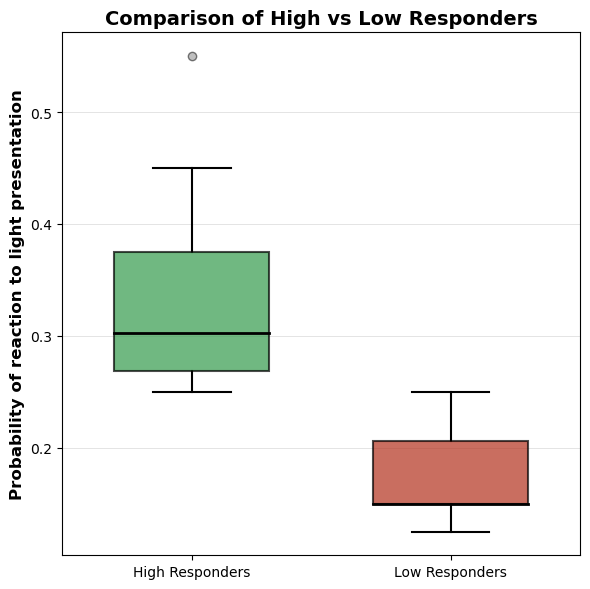


SUMMARY STATISTICS

High Responders (n=12):
  Mean: 0.340
  Median: 0.302
  Std Dev: 0.096
  Min: 0.250
  Max: 0.550

Low Responders (n=12):
  Mean: 0.171
  Median: 0.150
  Std Dev: 0.042
  Min: 0.125
  Max: 0.250

Independent t-test:
  t-statistic: 5.5818197572
  p-value: 0.0000130405


In [4]:
# Copy over the list of scores for the high group
high_LO_scores = [0.55, 0.45, 0.35, 0.3, 0.275, 0.25, 0.45, 0.35, 0.305, 0.3, 0.25, 0.25]

# Copy over the list of scores for the low group
low_LO_scores = [0.25, 0.225, 0.15, 0.15, 0.15, 0.125, 0.225, 0.2, 0.15, 0.15, 0.15, 0.125]

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))

# Create box plot
bp = ax.boxplot([high_LO_scores, low_LO_scores], 
                 labels=['High Responders', 'Low Responders'],
                 patch_artist=True,  # Enables color filling
                 widths=0.6,
                 showmeans=False,  # Show mean as well as median
                 meanline=False,  # Show mean as a point, not line
                 meanprops=dict(marker='D', markerfacecolor='white', 
                               markeredgecolor='black', markersize=6))

# Color the boxes
colors = ['#349B4C', '#B3311D']  # High (green), Low (red)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style the whiskers, caps, and medians
for whisker in bp['whiskers']:
    whisker.set(color='black', linewidth=1.5)

for cap in bp['caps']:
    cap.set(color='black', linewidth=1.5)

for median in bp['medians']:
    median.set(color='black', linewidth=2)

# Style the outlier markers (if any)
for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='gray', 
             markeredgecolor='black', markersize=6, alpha=0.5)

# Formatting
ax.set_ylabel('Probability of reaction to light presentation', fontsize=12, fontweight='bold')
ax.set_title('Comparison of High vs Low Responders', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

# Add sample size annotations
# ax.text(1, max(high_LO_scores) * 1.02, f'n={len(high_LO_scores)}', 
#         ha='center', va='bottom', fontsize=10, style='italic')
# ax.text(2, max(low_LO_scores) * 1.02, f'n={len(low_LO_scores)}', 
#         ha='center', va='bottom', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"\nHigh Responders (n={len(high_LO_scores)}):")
print(f"  Mean: {np.mean(high_LO_scores):.3f}")
print(f"  Median: {np.median(high_LO_scores):.3f}")
print(f"  Std Dev: {np.std(high_LO_scores, ddof=1):.3f}")
print(f"  Min: {np.min(high_LO_scores):.3f}")
print(f"  Max: {np.max(high_LO_scores):.3f}")

print(f"\nLow Responders (n={len(low_LO_scores)}):")
print(f"  Mean: {np.mean(low_LO_scores):.3f}")
print(f"  Median: {np.median(low_LO_scores):.3f}")
print(f"  Std Dev: {np.std(low_LO_scores, ddof=1):.3f}")
print(f"  Min: {np.min(low_LO_scores):.3f}")
print(f"  Max: {np.max(low_LO_scores):.3f}")

# Optional: Perform t-test
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(high_LO_scores, low_LO_scores)
print(f"\nIndependent t-test:")
print(f"  t-statistic: {t_stat:.10f}")
print(f"  p-value: {p_value:.10f}")
print("="*50)

## Duplicate box and whisker code, but with the extra discarded data

In [ ]:
# ==================== BOX AND WHISKER PLOT ====================

# Copy over the list of scores for the high group
high_LO_scores = [0.55, 0.45, 0.35, 0.3, 0.275, 0.25, 0.45, 0.35, 0.305, 0.3, 0.25, 0.25]

# Copy over the list of scores for the low group
low_LO_scores = [0.25, 0.225, 0.15, 0.15, 0.15, 0.125, 0.225, 0.2, 0.15, 0.15, 0.15, 0.125]

# Copy over the list of scores for the discarded group
discarded_LO_scores = [0.125, 0.125, 0.125, 0.1, 0.1, 0.075, 0.125, 0.125, 0.1, 0.1, 0.075, 0.075]

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Create box plot
bp = ax.boxplot([high_LO_scores, low_LO_scores, discarded_LO_scores], 
                 labels=['High Responders', 'Low Responders', 'Discarded'],
                 patch_artist=True,  # Enables color filling
                 widths=0.6,
                 showmeans=True,  # Show mean as well as median
                 meanline=False,  # Show mean as a point, not line
                 meanprops=dict(marker='D', markerfacecolor='white', 
                               markeredgecolor='black', markersize=6))

# Color the boxes
colors = ['#349B4C', '#B3311D', '#808080']  # High (green), Low (red), Discarded (gray)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Style the whiskers, caps, and medians
for whisker in bp['whiskers']:
    whisker.set(color='black', linewidth=1.5)

for cap in bp['caps']:
    cap.set(color='black', linewidth=1.5)

for median in bp['medians']:
    median.set(color='black', linewidth=2)

# Style the outlier markers (if any)
for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='gray', 
             markeredgecolor='black', markersize=6, alpha=0.5)

# Formatting
ax.set_ylabel('LO Score', fontsize=12, fontweight='bold')
ax.set_title('Comparison of High vs Low vs Discarded Responders', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)
ax.set_axisbelow(True)

# Add sample size annotations
max_high = max(high_LO_scores)
max_low = max(low_LO_scores)
max_discarded = max(discarded_LO_scores)
overall_max = max(max_high, max_low, max_discarded)

ax.text(1, overall_max * 1.02, f'n={len(high_LO_scores)}', 
        ha='center', va='bottom', fontsize=10, style='italic')
ax.text(2, overall_max * 1.02, f'n={len(low_LO_scores)}', 
        ha='center', va='bottom', fontsize=10, style='italic')
ax.text(3, overall_max * 1.02, f'n={len(discarded_LO_scores)}', 
        ha='center', va='bottom', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"\nHigh Responders (n={len(high_LO_scores)}):")
print(f"  Mean: {np.mean(high_LO_scores):.3f}")
print(f"  Median: {np.median(high_LO_scores):.3f}")
print(f"  Std Dev: {np.std(high_LO_scores, ddof=1):.3f}")
print(f"  Min: {np.min(high_LO_scores):.3f}")
print(f"  Max: {np.max(high_LO_scores):.3f}")

print(f"\nLow Responders (n={len(low_LO_scores)}):")
print(f"  Mean: {np.mean(low_LO_scores):.3f}")
print(f"  Median: {np.median(low_LO_scores):.3f}")
print(f"  Std Dev: {np.std(low_LO_scores, ddof=1):.3f}")
print(f"  Min: {np.min(low_LO_scores):.3f}")
print(f"  Max: {np.max(low_LO_scores):.3f}")

print(f"\nDiscarded (n={len(discarded_LO_scores)}):")
print(f"  Mean: {np.mean(discarded_LO_scores):.3f}")
print(f"  Median: {np.median(discarded_LO_scores):.3f}")
print(f"  Std Dev: {np.std(discarded_LO_scores, ddof=1):.3f}")
print(f"  Min: {np.min(discarded_LO_scores):.3f}")
print(f"  Max: {np.max(discarded_LO_scores):.3f}")

# Optional: Perform pairwise t-tests
from scipy.stats import ttest_ind
print(f"\nPairwise t-tests:")

t_stat_h_l, p_value_h_l = ttest_ind(high_LO_scores, low_LO_scores)
print(f"\n  High vs Low:")
print(f"    t-statistic: {t_stat_h_l:.10f}")
print(f"    p-value: {p_value_h_l:.10}")

t_stat_h_d, p_value_h_d = ttest_ind(high_LO_scores, discarded_LO_scores)
print(f"\n  High vs Discarded:")
print(f"    t-statistic: {t_stat_h_d:.10f}")
print(f"    p-value: {p_value_h_d:.10f}")

t_stat_l_d, p_value_l_d = ttest_ind(low_LO_scores, discarded_LO_scores)
print(f"\n  Low vs Discarded:")
print(f"    t-statistic: {t_stat_l_d:.10f}")
print(f"    p-value: {p_value_l_d:.10f}")

print("="*50)